In [1]:
import getpass
import os


def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")


_set_env("OPENAI_API_KEY")

In [2]:
from langchain_core.messages import AIMessage
from langchain_core.tools import tool

from langgraph.prebuilt import ToolNode
from state import AgentGraphState

In [3]:
@tool
def get_weather(location: str):
    """Call to get the current weather."""
    if location.lower() in ["sf", "san francisco"]:
        return "It's 60 degrees and foggy."
    else:
        return "It's 90 degrees and sunny."


@tool
def get_coolest_cities():
    """Get a list of coolest cities"""
    return "nyc, sf"

In [4]:
from langgraph.graph import StateGraph, MessagesState, START, END

def hello_world(state: AgentGraphState):
    return {"processed_email_body": state["processed_email_body"]}


In [5]:
import sys
import os

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add parent directory to sys.path
sys.path.append(parent_dir)

In [6]:
from tools.product_enquiry import product_enquiry
from tools.calendar import calender_availability


In [7]:
tools = [get_weather, get_coolest_cities]
tool_node = ToolNode(tools)

In [8]:
from typing import Literal
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, MessagesState
from langgraph.prebuilt import ToolNode


model_with_tools = ChatOpenAI(
    model="gpt-4o-mini", temperature=0
).bind_tools(tools)

In [9]:
from drafter_graph import create_email_drafter_graph


In [10]:
email_drafter_graph= create_email_drafter_graph(tools)

bind started sucessfully
bind completed sucessfully


In [11]:

def email_categorizer(state:AgentGraphState):
    response = email_drafter_graph.invoke({"messages": state["processed_email_body"]})
    print("response", response)
    return {"messages": [response]}

In [12]:
from typing import Literal

from langgraph.graph import StateGraph, MessagesState, START, END


def should_continue(state: AgentGraphState):
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END


def call_model(state: AgentGraphState):
    messages = state["messages"]
    print("messages ", messages)
    response = model_with_tools.invoke(messages)
    return {"messages": [response]}


workflow = StateGraph(AgentGraphState)
workflow.add_node("hello",hello_world )
# Define the two nodes we will cycle between
workflow.add_node("agent", email_categorizer)
# workflow.add_node("tools", tool_node)

workflow.add_edge(START, "hello")
workflow.add_edge("hello","agent")
# workflow.add_conditional_edges("agent", should_continue, ["tools", END])
# workflow.add_edge("tools", "agent")

app = workflow.compile()

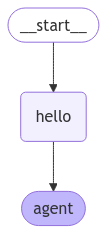

In [13]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [14]:
# example with a single tool call
app.invoke(
    {"processed_email_body": [("human", "what is the temperature in coool cities!")]})

messages [HumanMessage(content='what is the temperature in coool cities!', additional_kwargs={}, response_metadata={}, id='943fcee6-2cb4-48ea-94df-be73cad8e6fb')]
content='' additional_kwargs={'tool_calls': [{'id': 'call_TEH1mCsD769DpKZOgZIRATgt', 'function': {'arguments': '{}', 'name': 'get_coolest_cities'}, 'type': 'function'}], 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 72, 'total_tokens': 86, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6fc10e10eb', 'finish_reason': 'tool_calls', 'logprobs': None} id='run-0cf43dc1-f999-4925-b8ea-ec0319a8f59d-0' tool_calls=[{'name': 'get_coolest_cities', 'args': {}, 'id': 'call_TEH1mCsD769DpKZOgZIRATgt', 'type': 'tool_call'}] usage_metadata={'input_tokens': 72, 'output_tokens'

ValueError: Message dict must contain 'role' and 'content' keys, got {'messages': [HumanMessage(content='what is the temperature in coool cities!', additional_kwargs={}, response_metadata={}, id='943fcee6-2cb4-48ea-94df-be73cad8e6fb'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_TEH1mCsD769DpKZOgZIRATgt', 'function': {'arguments': '{}', 'name': 'get_coolest_cities'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 72, 'total_tokens': 86, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6fc10e10eb', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-0cf43dc1-f999-4925-b8ea-ec0319a8f59d-0', tool_calls=[{'name': 'get_coolest_cities', 'args': {}, 'id': 'call_TEH1mCsD769Dp

: 

In [ ]:
# example with a multiple tool calls in succession

# example with a multiple tool calls in succession

# response= app.invoke(
#     {"messages": [("human", "what's the weather in the coolest cities?")]}
# )


In [ ]:
# response